In [1]:
%load_ext autoreload
%autoreload 2

In [13]:
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
import matplotlib.gridspec as gridspec
from torchvision.transforms.functional import to_pil_image

In [38]:
# def cjfun(t):
#     t = F.adjust_brightness(t, 0.5)
#     t = F.adjust_contrast(t, 0.4)
#     t = F.adjust_saturation(t, 0.1)
#     t = F.adjust_hue(t, 0.2)
#     return t
def cjfun(t):
    t = F.adjust_brightness(t, 0.6)
    t = F.adjust_contrast(t, 0.4)
    t = F.adjust_saturation(t, 0.4)
    t = F.adjust_hue(t, 0.2)
    return t
def cropfun(t, size = 28):
    scale = (0.08, 1.0)
    ratio = (0.75, 1.3333333333333333)

    image_height,image_width=size,size
    random_scale = random.uniform(scale[0], scale[1])

    random_ratio = random.uniform(ratio[0], ratio[1])

    height = int(random_scale * random_ratio * image_height)
    width = int(random_scale * image_width)

    top = random.randint(0, image_height - height)
    left = random.randint(0, image_width - width)
    return F.resized_crop(t, top=top, left=left,
                           height=height, width=width, 
                           size=[size, size])

def get_image_midpoint(t_im1,xybox_cord,zoom):
        pil_img = to_pil_image(t_im1) 
        img_width, img_height = pil_img.size

       
        zoom_factor = zoom

   
        half_width = (img_width * zoom_factor) / 2
        half_height = (img_height * zoom_factor) / 2

        image_center_x, image_center_y = xybox_cord

        
        top_left_y = image_center_y + half_height
        bottom_left_y = image_center_y - half_height

        
        left_x = image_center_x - half_width

        midpoint_left_x = left_x  
        midpoint_left_y = (top_left_y + bottom_left_y) / 2  

        midpoint_left = (midpoint_left_x, midpoint_left_y)

        return midpoint_left



img_augmentations = {
    "H_Flip": F.hflip, 
    "Crop": cropfun,
    "Jitter": cjfun,
    "Grayscale": F.to_grayscale,   
}

In [4]:
data_root = "/home/berens/bep973/ifeoma_home/data/NAKO"

In [ ]:
!ls /home/berens/bep973/ifeoma_home/data/NAKO/images_lowres/224/rt_leftcentral

In [16]:
image=Image.open(f'{data_root}/images_lowres/224/rt_leftcentral/100000.jpg')#.resize((28,28))

original_image = Image.fromarray(np.array(image))

In [43]:
import torch
from torchvision import transforms

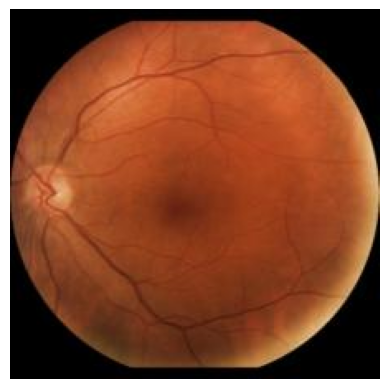

In [48]:
plt.imshow(transforms.ToTensor()(original_image).permute(1, 2, 0))
plt.axis('off')
plt.savefig('figures/original.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.savefig('figures/original.pdf', bbox_inches='tight', pad_inches=0, dpi=300)

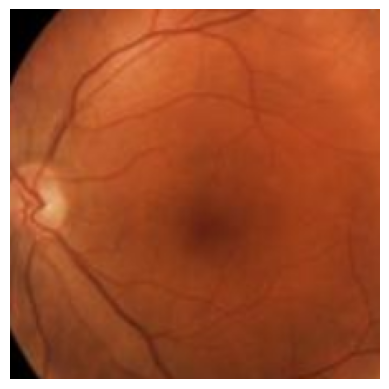

In [37]:
tr = img_augmentations["Crop"]
plt.imshow(cropfun(original_image, 224))
plt.axis('off')
plt.savefig('figures/cropfun.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.savefig('figures/cropfun.pdf', bbox_inches='tight', pad_inches=0, dpi=300)

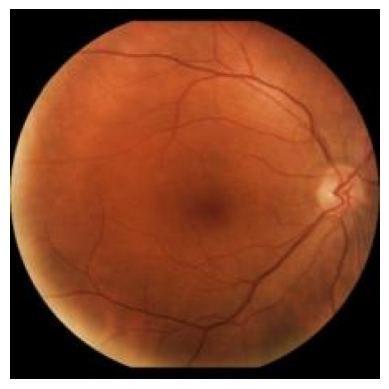

In [39]:
tr = img_augmentations["H_Flip"]
plt.imshow(tr(original_image), cmap="gray")
plt.axis('off')
plt.savefig('figures/h_flip.png', bbox_inches='tight', pad_inches=0, dpi=300)
plt.savefig('figures/h_flip.pdf', bbox_inches='tight', pad_inches=0, dpi=300)

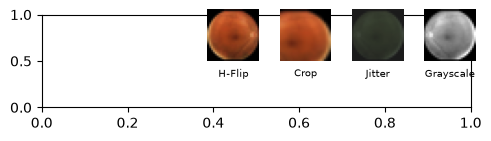

In [14]:
fig, axes = plt.subplots(figsize=(4.8, 1.3),constrained_layout=True)
grid_rows, grid_cols = 2, 7

gs = gridspec.GridSpec(grid_rows, grid_cols, figure=fig)
# Iterate over img_augmentations and our_augmentations to create right side subplots
for i, (title, tr) in enumerate(img_augmentations.items()):
    ax = fig.add_subplot(gs[0, 3 + i])
    ax.set_axis_off()
    ax.imshow(tr(original_image), cmap="gray")
    title_y_position = -0.15
    ax.text(0.5, title_y_position, title, ha='center', va='top', transform=ax.transAxes, fontsize=7)
